In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 

df = pd.read_csv("GHG_emissions_output_naei23 (1).csv")


In [2]:
#Understanding the data

In [3]:
df.head()

,GasID,Gas,NFR/CRT Code,NFR/CRT Description,Sourcecode,SourceName,Activitycode,ActivityName,Emission_Unit,Year,Emission
0,2,Carbon Dioxide as Carbon,1A1ai,Public electricity generation,33,Power stations,7,Coal,kilotonne,1990,49949.948922
1,2,Carbon Dioxide as Carbon,1A1ai,Public electricity generation,33,Power stations,7,Coal,kilotonne,1991,50185.842470
2,2,Carbon Dioxide as Carbon,1A1ai,Public electricity generation,33,Power stations,7,Coal,kilotonne,1992,46898.598572
3,2,Carbon Dioxide as Carbon,1A1ai,Public electricity generation,33,Power stations,7,Coal,kilotonne,1993,39044.702153
4,2,Carbon Dioxide as Carbon,1A1ai,Public electricity generation,33,Power stations,7,Coal,kilotonne,1994,36854.359195


In [4]:
df.tail()

,GasID,Gas,NFR/CRT Code,NFR/CRT Description,Sourcecode,SourceName,Activitycode,ActivityName,Emission_Unit,Year,Emission
139021,Total GHGs in CO2 Eq.,Total GHGs in CO2 Eq.,2F1d,Transport refrigeration refrigerant leakage,1165,"Transport Refrigeration: Systems for vans, lig...",372,Halocarbon in products at disposal: HFC-32,kilotonne,2019,NaN
139022,Total GHGs in CO2 Eq.,Total GHGs in CO2 Eq.,2F1d,Transport refrigeration refrigerant leakage,1165,"Transport Refrigeration: Systems for vans, lig...",372,Halocarbon in products at disposal: HFC-32,kilotonne,2020,NaN
139023,Total GHGs in CO2 Eq.,Total GHGs in CO2 Eq.,2F1d,Transport refrigeration refrigerant leakage,1165,"Transport Refrigeration: Systems for vans, lig...",372,Halocarbon in products at disposal: HFC-32,kilotonne,2021,NaN
139024,Total GHGs in CO2 Eq.,Total GHGs in CO2 Eq.,2F1d,Transport refrigeration refrigerant leakage,1165,"Transport Refrigeration: Systems for vans, lig...",372,Halocarbon in products at disposal: HFC-32,kilotonne,2022,0.001791
139025,Total GHGs in CO2 Eq.,Total GHGs in CO2 Eq.,2F1d,Transport refrigeration refrigerant leakage,1165,"Transport Refrigeration: Systems for vans, lig...",372,Halocarbon in products at disposal: HFC-32,kilotonne,2023,0.007120


In [5]:
print("Shape:", df.shape)


Shape: (139026, 11)


In [6]:
df.columns

Index(['GasID', 'Gas', 'NFR/CRT Code', 'NFR/CRT Description', 'Sourcecode',
       'SourceName', 'Activitycode', 'ActivityName', 'Emission_Unit', 'Year',
       'Emission'],
      dtype='str')

In [7]:
df.nunique()

GasID                       8
Gas                         8
NFR/CRT Code              213
NFR/CRT Description       213
Sourcecode                577
SourceName                567
Activitycode              227
ActivityName              227
Emission_Unit               2
Year                       34
Emission               101983
dtype: int64

In [8]:
df["Gas"].unique()

<ArrowStringArray>
['Carbon Dioxide as Carbon',                  'Methane',
            'Nitrous Oxide',                     'HFCs',
                      'NF3',                     'PFCs',
     'Sulphur hexafluoride',    'Total GHGs in CO2 Eq.']
Length: 8, dtype: str

In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 139026 entries, 0 to 139025
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   GasID                139026 non-null  str    
 1   Gas                  139026 non-null  str    
 2   NFR/CRT Code         139026 non-null  str    
 3   NFR/CRT Description  139026 non-null  str    
 4   Sourcecode           139026 non-null  int64  
 5   SourceName           139026 non-null  str    
 6   Activitycode         139026 non-null  int64  
 7   ActivityName         139026 non-null  str    
 8   Emission_Unit        139026 non-null  str    
 9   Year                 139026 non-null  int64  
 10  Emission             113752 non-null  float64
dtypes: float64(1), int64(3), str(7)
memory usage: 29.6 MB


In [10]:
df.describe()


,Sourcecode,Activitycode,Year,Emission
count,139026.000000,139026.000000,139026.000000,113752.000000
mean,3271.142822,390.110296,2006.500000,250.407167
std,3527.434311,330.796762,9.810744,2609.937881
min,2.000000,1.000000,1990.000000,-19939.108178
25%,551.000000,21.000000,1998.000000,0.010198
50%,1156.000000,362.000000,2006.500000,0.398673
75%,8011.000000,803.000000,2015.000000,17.846529
max,8378.000000,899.000000,2023.000000,185001.296819


In [11]:
#cleaning the data

In [12]:
df.isnull().sum()  # finding the null values in dataste


GasID                      0
Gas                        0
NFR/CRT Code               0
NFR/CRT Description        0
Sourcecode                 0
SourceName                 0
Activitycode               0
ActivityName               0
Emission_Unit              0
Year                       0
Emission               25274
dtype: int64

In [13]:
df = df.dropna()  # removing the null values in the dataset


In [14]:
#Removing unwanted cols and keeping only required cols
cols_to_drop = [
    'GasID',
    'NFR/CRT Code',
    'NFR/CRT Description',
    'Sourcecode',
    'Activitycode',
    'Emission_Unit'
]

df = df.drop(columns=cols_to_drop)

In [15]:
df.head()

,Gas,SourceName,ActivityName,Year,Emission
0,Carbon Dioxide as Carbon,Power stations,Coal,1990,49949.948922
1,Carbon Dioxide as Carbon,Power stations,Coal,1991,50185.842470
2,Carbon Dioxide as Carbon,Power stations,Coal,1992,46898.598572
3,Carbon Dioxide as Carbon,Power stations,Coal,1993,39044.702153
4,Carbon Dioxide as Carbon,Power stations,Coal,1994,36854.359195


In [16]:
# Relationship between varibles

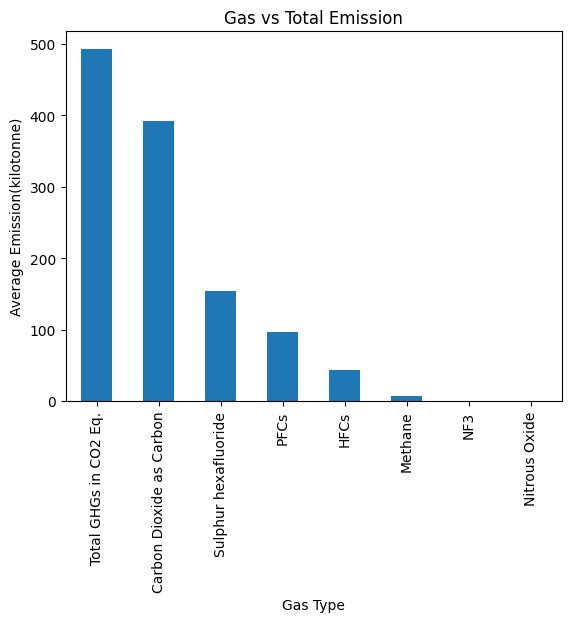

In [17]:
# ---- Gas vs Emission ----
import matplotlib.pyplot as plt
gas_emission = df.groupby('Gas')['Emission'].mean().sort_values(ascending=False)
plt.figure()
gas_emission.plot(kind='bar')
plt.xlabel("Gas Type")
plt.ylabel("Average Emission(kilotonne)")
plt.title("Gas vs Total Emission")
plt.savefig("Gas vs T emission.png")
plt.show()

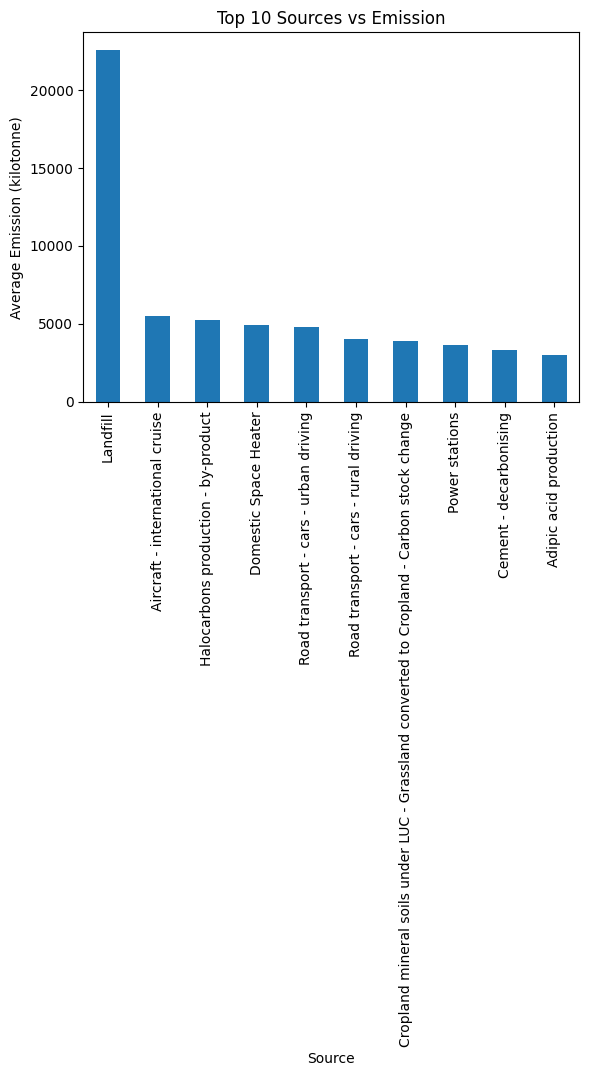

In [18]:
# ---- Source vs Emission ----
source_emission = df.groupby('SourceName')['Emission'].mean().sort_values(ascending=False).head(10)
plt.figure()
source_emission.plot(kind='bar')
plt.xlabel("Source")
plt.ylabel("Average Emission (kilotonne)")
plt.title("Top 10 Sources vs Emission")
plt.savefig("Source vs avg emission.png")
plt.show()

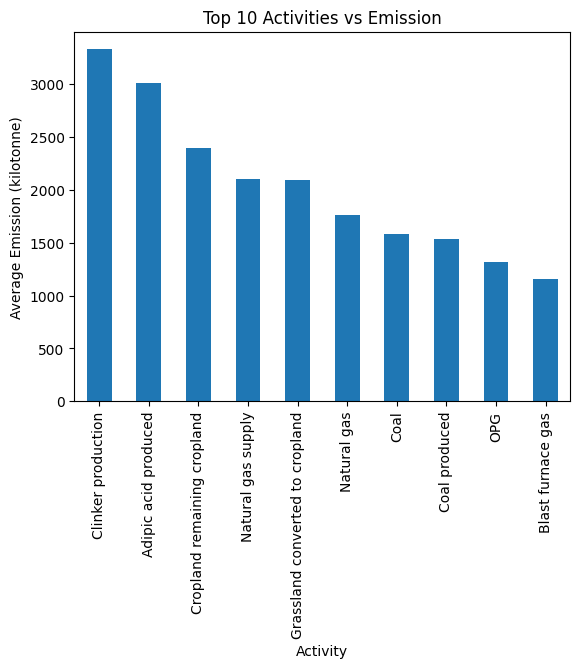

In [19]:
# ---- Activity vs Emission ----
activity_emission = df.groupby('ActivityName')['Emission'].mean().sort_values(ascending=False).head(10)
plt.figure()
activity_emission.plot(kind='bar')
plt.xlabel("Activity")
plt.ylabel("Average Emission (kilotonne)")
plt.title("Top 10 Activities vs Emission")
plt.show()

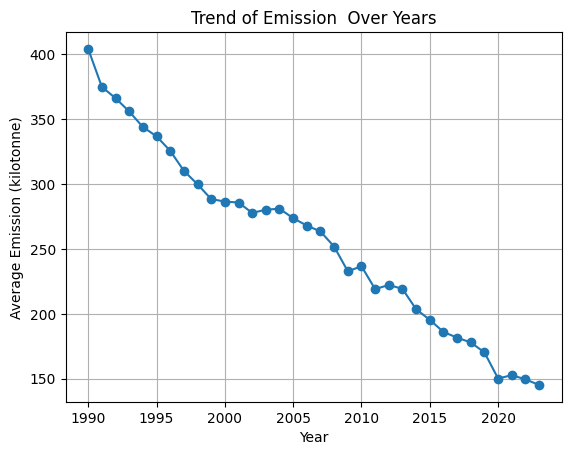

In [20]:
# ---- Year vs Emission (Trend Line) ----
year_emission = df.groupby('Year')['Emission'].mean()

plt.figure()
year_emission.plot(marker='o') 
plt.xlabel("Year")
plt.ylabel("Average Emission (kilotonne)")
plt.title("Trend of Emission  Over Years")
plt.grid(True)
plt.savefig("linegraph.png")
plt.show()


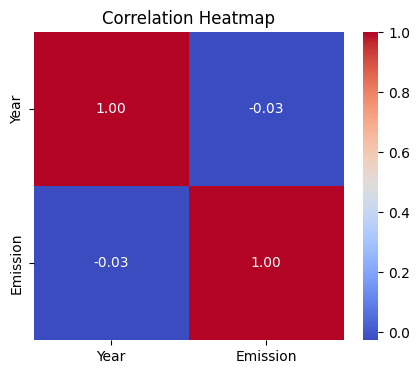

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

#numeric columns
numeric_df = df[['Year', 'Emission']]

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [22]:
#Model1

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score,roc_curve, accuracy_score, precision_score, recall_score




In [24]:
print(df.columns)

Index(['Gas', 'SourceName', 'ActivityName', 'Year', 'Emission'], dtype='str')


In [25]:
df = df[['Gas', 'SourceName','ActivityName', 'Year', 'Emission']]
df.head()

,Gas,SourceName,ActivityName,Year,Emission
0,Carbon Dioxide as Carbon,Power stations,Coal,1990,49949.948922
1,Carbon Dioxide as Carbon,Power stations,Coal,1991,50185.842470
2,Carbon Dioxide as Carbon,Power stations,Coal,1992,46898.598572
3,Carbon Dioxide as Carbon,Power stations,Coal,1993,39044.702153
4,Carbon Dioxide as Carbon,Power stations,Coal,1994,36854.359195


In [26]:
df = df.sort_values(['Gas', 'SourceName', 'ActivityName','Year'])
df.head()

,Gas,SourceName,ActivityName,Year,Emission
10098,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1990,3.084723
10099,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1991,2.382917
10100,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1992,2.763347
10101,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1993,3.598210
10102,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1994,3.743416


In [27]:
df['Previous_Emission'] = df.groupby(['Gas', 'SourceName', 'ActivityName'])['Emission'].shift(1)

df['Emission_Rise'] = (df['Emission'] > df['Previous_Emission']).astype(int)


df = df.dropna()

df.head()

,Gas,SourceName,ActivityName,Year,Emission,Previous_Emission,Emission_Rise
10099,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1991,2.382917,3.084723,0
10100,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1992,2.763347,2.382917,1
10101,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1993,3.598210,2.763347,1
10102,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1994,3.743416,3.598210,1
10103,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1995,3.734793,3.743416,0


In [28]:
le_gas = LabelEncoder()
le_sector = LabelEncoder()
le_Activity = LabelEncoder()

df['Gas_encoded'] = le_gas.fit_transform(df['Gas'])
df['Sector_encoded'] = le_sector.fit_transform(df['SourceName'])
df['Activity_encoded']= le_Activity.fit_transform(df['ActivityName'])

df.head()

,Gas,SourceName,ActivityName,Year,Emission,Previous_Emission,Emission_Rise,Gas_encoded,Sector_encoded,Activity_encoded
10099,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1991,2.382917,3.084723,0,0,13,113
10100,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1992,2.763347,2.382917,1,0,13,113
10101,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1993,3.598210,2.763347,1,0,13,113
10102,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1994,3.743416,3.598210,1,0,13,113
10103,Carbon Dioxide as Carbon,Agricultural engines,Lubricants,1995,3.734793,3.743416,0,0,13,113


In [29]:
X = df[['Gas_encoded', 'Sector_encoded', 'Activity_encoded','Year']]
y = df['Emission_Rise']

X.head(), y.head()

(       Gas_encoded  Sector_encoded  Activity_encoded  Year
 10099            0              13               113  1991
 10100            0              13               113  1992
 10101            0              13               113  1993
 10102            0              13               113  1994
 10103            0              13               113  1995,
 10099    0
 10100    1
 10101    1
 10102    1
 10103    0
 Name: Emission_Rise, dtype: int64)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(87730, 4)
(21933, 4)


In [31]:
model = RandomForestClassifier(n_estimators=100, random_state=42, criterion="entropy")

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

In [32]:
y_prob = model.predict_proba(X_test)[:, 1]
print(y_prob)

[0.99 1.   0.32 ... 0.94 1.   0.84]


In [33]:
thresholds = np.arange(0.1, 0.9, 0.01)
best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    y_pred_temp = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)

Best Threshold: 0.44999999999999984


In [34]:
y_pred = (y_prob >= best_threshold).astype(int)

In [35]:
print("Best Threshold:", best_threshold)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

RF_accu = accuracy_score(y_test, y_pred)
RF_precision = precision_score(y_test, y_pred)
RF_recall = recall_score(y_test, y_pred)
RF_f1 = f1_score(y_test, y_pred)
RF_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", RF_accu)
print("Precision:", RF_precision)
print("Recall:",RF_recall )
print("F1 Score:", RF_f1)
print("ROC-AUC Score:", RF_auc)


Best Threshold: 0.44999999999999984

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.80      0.83     10716
           1       0.82      0.87      0.85     11217

    accuracy                           0.84     21933
   macro avg       0.84      0.84      0.84     21933
weighted avg       0.84      0.84      0.84     21933

Accuracy: 0.8384169972188027
Precision: 0.8235641393269798
Recall: 0.8705536239636267
F1 Score: 0.8464072115801334
ROC-AUC Score: 0.9271155865009594


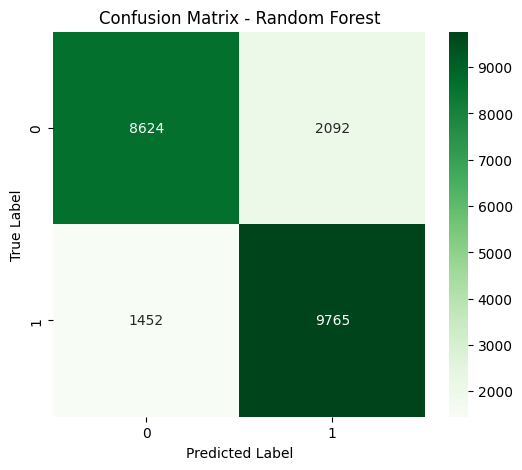

In [36]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")

# Save image
plt.savefig("confusion_matrix_rf.png", dpi=300, bbox_inches='tight')

# Show plot
plt.show()

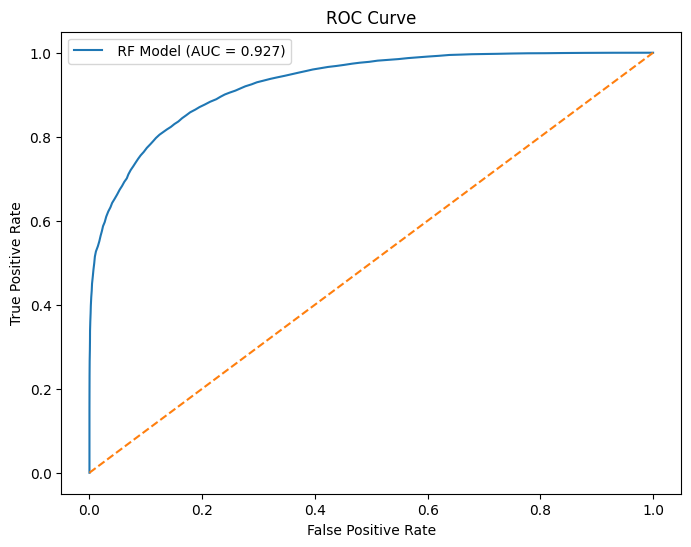

In [37]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f" RF Model (AUC = {RF_auc:.3f})")

# Random classifier line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [38]:
#model 2

In [39]:
from xgboost import XGBClassifier

In [40]:
# Train XGBoost model
model_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
   
)

In [41]:
model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [42]:
# Probability predictions
y_prob_xgb = model_xgb.predict_proba(X_test)[:,1]

In [43]:
# Threshold optimization
thresholds = np.arange(0.1, 0.9, 0.01)
best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    y_pred_temp = (y_prob_xgb >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)

Best Threshold: 0.4199999999999998


In [44]:
# Final predictions
y_pred_xgb = (y_prob_xgb >= best_threshold).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGB_accu = accuracy_score(y_test, y_pred_xgb)
XGB_precision = precision_score(y_test, y_pred_xgb)
XGB_recall = recall_score(y_test, y_pred_xgb)
XGB_f1 = f1_score(y_test, y_pred_xgb)
XGB_auc = roc_auc_score(y_test, y_prob_xgb)

print("Accuracy:", XGB_accu)
print("Precision:", XGB_precision)
print("Recall:", XGB_recall)
print("F1 Score:", XGB_f1)
print("ROC-AUC Score:", XGB_auc)

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))


Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.46      0.58     10716
           1       0.63      0.87      0.73     11217

    accuracy                           0.67     21933
   macro avg       0.70      0.66      0.65     21933
weighted avg       0.70      0.67      0.65     21933

Accuracy: 0.6688551497743127
Precision: 0.6274990326325294
Recall: 0.8674333600784524
F1 Score: 0.728211652883284
ROC-AUC Score: 0.7819694687012391

Confusion Matrix:

[[4940 5776]
 [1487 9730]]


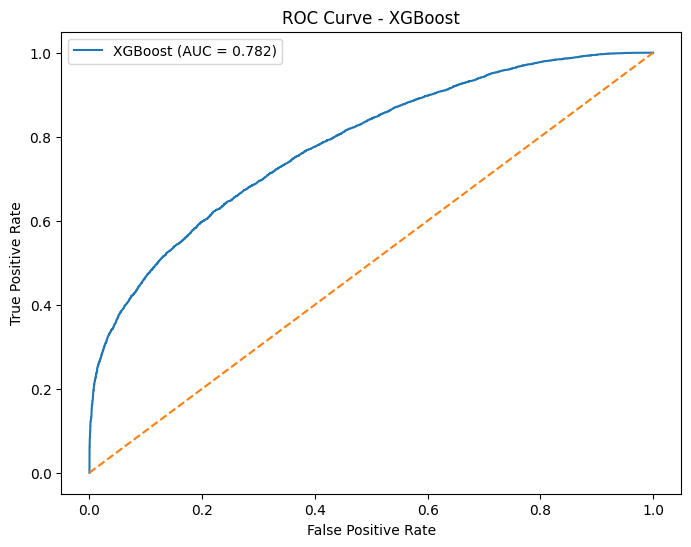

In [45]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {XGB_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--')  # Random classifier

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

In [46]:
#model3

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [48]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
# Create Logistic Regression model
model_lr = LogisticRegression(max_iter=1000, random_state=42)

In [50]:
# Train the model
model_lr.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [51]:
# Predict probabilities
y_pred_lr = model_lr.predict(X_test_scaled)
y_prob_lr = model_lr.predict_proba(X_test_scaled)[:,1]

In [52]:
# Threshold optimization
thresholds = np.arange(0.1, 0.9, 0.01)
best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    y_pred_temp = (y_prob_lr >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)

Best Threshold: 0.1


In [53]:
# Final predictions
y_pred_lr = (y_prob_lr >= best_threshold).astype(int)

# Evaluation metrics
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr,zero_division=0))

LOG_accu = accuracy_score(y_test, y_pred_lr)
LOG_precision = precision_score(y_test, y_pred_lr)
LOG_recall = recall_score(y_test, y_pred_lr)
LOG_f1 = f1_score(y_test, y_pred_lr)
LOG_auc = roc_auc_score(y_test, y_prob_lr)

print("Accuracy:", LOG_accu)
print("Precision:", LOG_precision)
print("Recall:", LOG_recall)
print("F1 Score:", LOG_f1)
print("ROC-AUC Score:", LOG_auc)

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     10716
           1       0.51      1.00      0.68     11217

    accuracy                           0.51     21933
   macro avg       0.26      0.50      0.34     21933
weighted avg       0.26      0.51      0.35     21933

Accuracy: 0.5114211462180276
Precision: 0.5114211462180276
Recall: 1.0
F1 Score: 0.6767420814479638
ROC-AUC Score: 0.5268294774538846

Confusion Matrix:

[[    0 10716]
 [    0 11217]]


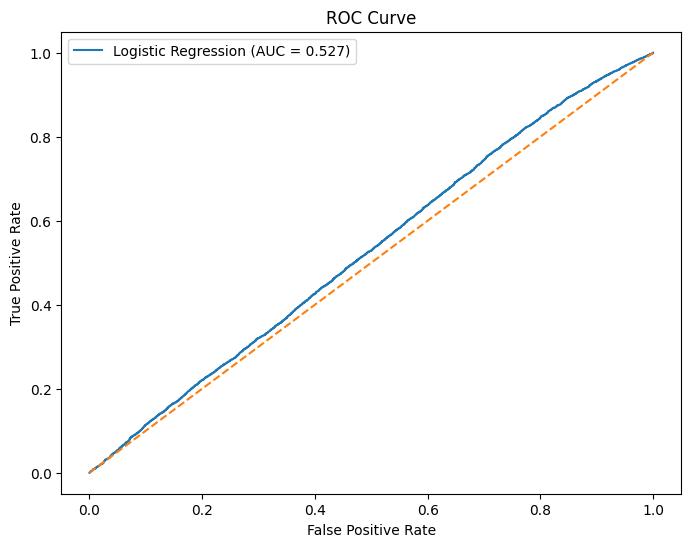

In [54]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")

# Random classifier line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [55]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Logistic Regression'],
    'Accuracy': [RF_accu, XGB_accu, LOG_accu],
    'Precision': [RF_precision, XGB_precision, LOG_precision],
    'Recall': [RF_recall, XGB_recall, LOG_recall],
    'F1 Score': [RF_f1, XGB_f1, LOG_f1],
    'ROC-AUC': [RF_auc, XGB_auc, LOG_auc]
})

print("\nModel Comparison:\n", results.round(3))


Model Comparison:
                  Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0        Random Forest     0.838      0.824   0.871     0.846    0.927
1              XGBoost     0.669      0.627   0.867     0.728    0.782
2  Logistic Regression     0.511      0.511   1.000     0.677    0.527


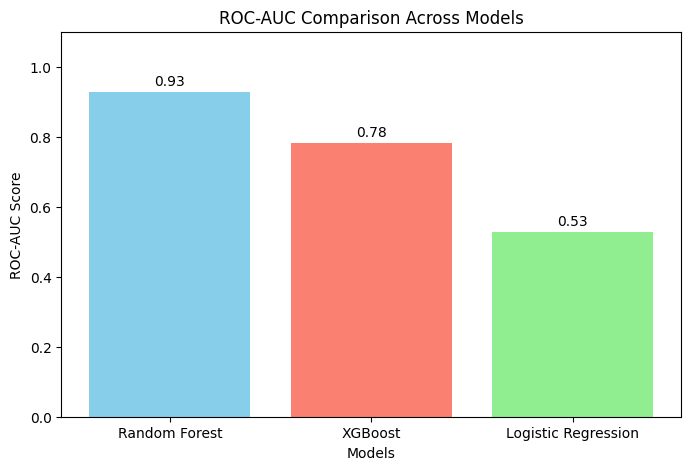

In [56]:
import matplotlib.pyplot as plt

# Models and their ROC-AUC scores
models = ['Random Forest', 'XGBoost', 'Logistic Regression']
roc_scores = [RF_auc, XGB_auc, LOG_auc]

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(models, roc_scores,color=['skyblue', 'salmon', 'lightgreen'])
plt.ylim(0, 1.1)  # ROC-AUC ranges from 0 to 1
plt.xlabel('Models')
plt.ylabel('ROC-AUC Score')
plt.title('ROC-AUC Comparison Across Models')

# Show values on top of bars
for i, score in enumerate(roc_scores):
    plt.text(i, score + 0.02, f'{score:.2f}', ha='center', fontsize=10)

plt.show()

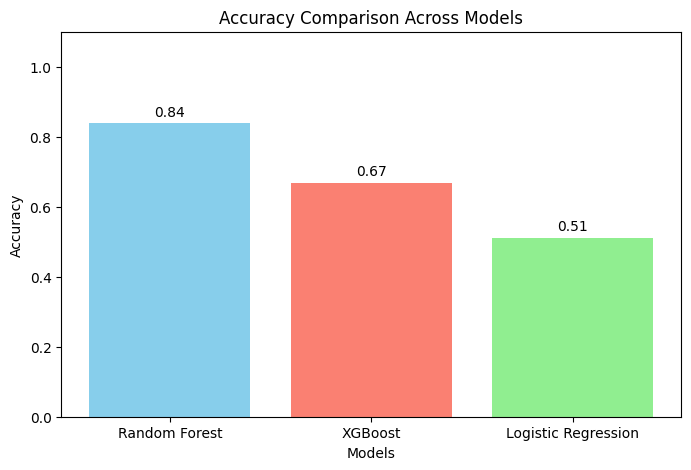

In [57]:
import matplotlib.pyplot as plt

# Models and their Accuracy scores
models = ['Random Forest', 'XGBoost', 'Logistic Regression']
accuracy_scores = [RF_accu, XGB_accu, LOG_accu]

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(models, accuracy_scores, color=['skyblue', 'salmon', 'lightgreen'])
plt.ylim(0, 1.1)  # Accuracy ranges from 0 to 1
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison Across Models')

# Show values on top of bars
for i, score in enumerate(accuracy_scores):
    plt.text(i, score + 0.02, f'{score:.2f}', ha='center', fontsize=10)

plt.show()